# Results Overview — `career_position` Annotation

Aggregates all submitted results from `results/register.csv` for the `annotation / career_position` task.
Models are grouped by architecture family for both **broad** (9 sectors) and **fine-grained** (~100 codes) granularities.

> Run all cells top-to-bottom to regenerate after new results are submitted.

## 1. Imports & config

In [37]:
import json as _json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "white"

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np

REGISTER = Path("/home/tom/projects/corex_eval/results/register.csv")
TASK     = "annotation"
VAR      = "career_position"

SECTOR_NAMES = {
    "1": "Executive (Ministers)",
    "2": "Gov. Administration",
    "3": "Public Sector",
    "4": "Legislature",
    "5": "Judiciary / Courts",
    "6": "Party / Politics",
    "7": "Private Sector",
    "8": "Civil Society / NGO",
    "9": "International Org.",
}

## 2. Model catalogue

In [38]:
# (family, display_name, experiment_folder_broad, experiment_folder_fine)
CATALOGUE = [
    # Encoders
    ("Encoder", "mBERT",            "bert_finetuned_career_broad",         "bert_finetuned_career"),
    ("Encoder", "BERT-EN",          "bert_english_finetuned_career_broad", "bert_english_finetuned_career"),
    ("Encoder", "XLM-RoBERTa",      "xlmroberta_finetuned_career_broad",   "xlmroberta_finetuned_career"),
    # Open-source LLMs
    ("OSS LLM", "GPT-OSS 20B",      "lmstudio_gptoss20b_broad",            "lmstudio_gptoss20b_fine"),
    ("OSS LLM", "Llama 3.3 70B",    "lmstudio_llama33_70b_broad",          "lmstudio_llama33_70b_fine"),
    ("OSS LLM", "Qwen3 80B",        "lmstudio_qwen3_80b_broad",            "lmstudio_qwen3_80b_fine"),
    # Closed-source LLMs
    ("Closed",  "GPT-4o",           "gpt4o_broad",                         "gpt4o_fine"),
    ("Closed",  "GPT-5.3",          "gpt53_broad",                         "gpt53_fine"),
    ("Closed",  "Claude Opus 4.6",  "claude_opus46_broad",                 "claude_opus46_fine"),
    ("Closed",  "Gemini 2.5 Flash", "gemini25flash_broad",                 "gemini25flash_fine"),
    # RAG
    ("RAG",     "RAG-Embeddings",   "rag_embeddings_broad",                "rag_embeddings_fine"),
    ("RAG",     "RAG-WebSearch",    "rag_websearch_broad",                 "rag_websearch_fine"),
]

FAMILY_ORDER  = ["Encoder", "OSS LLM", "Closed", "RAG"]
FAMILY_COLORS = {
    "Encoder": "#4C72B0",
    "OSS LLM": "#55A868",
    "Closed":  "#C44E52",
    "RAG":     "#DD8452",
}

print(f"{len(CATALOGUE)} experiments in catalogue")

12 experiments in catalogue


## 3. Load register

In [39]:
reg = pd.read_csv(REGISTER)
reg = reg[(reg["task"] == TASK) & (reg["variable"] == VAR)].copy()
print(f"Total rows after task/variable filter: {len(reg)}")

def _folder(path):
    parts = str(path).replace("\\\\", "/").split("/")
    return parts[-2] if len(parts) >= 2 else str(path)

reg["exp_folder"] = reg["experiment_path"].apply(_folder)

for col in ["accuracy", "macro_f1", "weighted_f1"]:
    reg[col] = pd.to_numeric(reg[col], errors="coerce")

# Keep best-accuracy row per experiment folder; drop zero/broken rows
reg_best = (
    reg[reg["accuracy"] > 0]
    .sort_values("accuracy", ascending=False)
    .drop_duplicates(subset="exp_folder", keep="first")
    .set_index("exp_folder")
)

print(f"Valid result rows: {len(reg_best)}")
print("Matched folders:", sorted(reg_best.index.tolist()))

Total rows after task/variable filter: 21
Valid result rows: 21
Matched folders: ['bert_english_finetuned_career', 'bert_english_finetuned_career_broad', 'bert_finetuned_career', 'bert_finetuned_career_broad', 'claude_opus46_broad', 'config.yaml', 'gemini25flash_broad', 'gemini25flash_fine', 'gpt4o_broad', 'gpt4o_fine', 'gpt53_broad', 'lmstudio_gptoss20b_broad', 'lmstudio_gptoss20b_fine', 'lmstudio_llama33_70b_broad', 'lmstudio_llama33_70b_fine', 'lmstudio_qwen3_80b_broad', 'lmstudio_qwen3_80b_fine', 'rag_embeddings_broad', 'rag_websearch_broad', 'xlmroberta_finetuned_career', 'xlmroberta_finetuned_career_broad']


## 4. Build results tables

In [40]:
def build_df(granularity):
    records = []
    for family, name, broad_folder, fine_folder in CATALOGUE:
        folder = broad_folder if granularity == "broad" else fine_folder
        if folder in reg_best.index:
            row = reg_best.loc[folder]
            records.append({
                "Family":      family,
                "Model":       name,
                "Accuracy":    round(float(row["accuracy"]),    4),
                "Macro F1":    round(float(row["macro_f1"]),    4) if pd.notna(row["macro_f1"])    else None,
                "Weighted F1": round(float(row["weighted_f1"]), 4) if pd.notna(row["weighted_f1"]) else None,
            })
        else:
            records.append({"Family": family, "Model": name,
                            "Accuracy": None, "Macro F1": None, "Weighted F1": None})
    df = pd.DataFrame(records)
    df["Family"] = pd.Categorical(df["Family"], categories=FAMILY_ORDER, ordered=True)
    return df.sort_values(["Family", "Model"]).reset_index(drop=True)

df_broad = build_df("broad")
df_fine  = build_df("fine")

## 5. Broad sector results (9 classes)

In [34]:
def fmt_table(df):
    d = df.copy()
    for col in ["Accuracy", "Macro F1", "Weighted F1"]:
        d[col] = d[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "TBD")
    return d.style.hide(axis="index")

fmt_table(df_broad)

Family,Model,Accuracy,Macro F1,Weighted F1
Encoder,BERT-EN,0.7670,0.6711,0.7624
Encoder,XLM-RoBERTa,0.7641,0.5819,0.7578
Encoder,mBERT,0.7630,0.6595,0.7578
OSS LLM,GPT-OSS 20B,0.6085,0.3154,0.6116
OSS LLM,Llama 3.3 70B,0.6245,0.4559,0.6150
OSS LLM,Qwen3 80B,0.6054,0.4482,0.6006
Closed,Claude Opus 4.6,0.6690,0.5166,0.6670
Closed,GPT-4o,0.6358,0.4777,0.6354
Closed,GPT-5.3,0.6642,0.4934,0.6611
Closed,Gemini 2.5 Flash,0.5390,0.4464,0.5971


In [35]:
def to_latex(df, caption, label):
    """Render a results DataFrame as a LaTeX booktabs table."""
    d = df.copy()
    for col in ["Accuracy", "Macro F1", "Weighted F1"]:
        d[col] = d[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "--")
    rows = []
    prev_fam = None
    for _, r in d.iterrows():
        if prev_fam is not None and r["Family"] != prev_fam:
            rows.append(r"\midrule")
        prev_fam = r["Family"]
        fam  = r["Family"].replace("&", r"\&")
        name = r["Model"].replace("&", r"\&")
        rows.append(f"{fam} & {name} & {r['Accuracy']} & {r['Macro F1']} & {r['Weighted F1']} \\\\")
    body = "\n".join(rows)
    return (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        "\\small\n"
        "\\begin{tabular}{llccc}\n"
        "\\toprule\n"
        "Family & Model & Accuracy & Macro F1 & Weighted F1 \\\\\n"
        "\\midrule\n"
        + body + "\n"
        "\\bottomrule\n"
        "\\end{tabular}\n"
        f"\\caption{{{caption}}}\n"
        f"\\label{{tab:{label}}}\n"
        "\\end{table}"
    )

print(to_latex(df_broad,
    caption="career\\_position annotation — Broad sectors (9 classes)",
    label="career_broad"))

\begin{table}[ht]
\centering
\small
\begin{tabular}{llccc}
\toprule
Family & Model & Accuracy & Macro F1 & Weighted F1 \\
\midrule
Encoder & BERT-EN & 0.7670 & 0.6711 & 0.7624 \\
Encoder & XLM-RoBERTa & 0.7641 & 0.5819 & 0.7578 \\
Encoder & mBERT & 0.7630 & 0.6595 & 0.7578 \\
\midrule
OSS LLM & GPT-OSS 20B & 0.6085 & 0.3154 & 0.6116 \\
OSS LLM & Llama 3.3 70B & 0.6245 & 0.4559 & 0.6150 \\
OSS LLM & Qwen3 80B & 0.6054 & 0.4482 & 0.6006 \\
\midrule
Closed & Claude Opus 4.6 & 0.6690 & 0.5166 & 0.6670 \\
Closed & GPT-4o & 0.6358 & 0.4777 & 0.6354 \\
Closed & GPT-5.3 & 0.6642 & 0.4934 & 0.6611 \\
Closed & Gemini 2.5 Flash & 0.5390 & 0.4464 & 0.5971 \\
\midrule
RAG & RAG-Embeddings & 0.8021 & 0.5517 & 0.7988 \\
RAG & RAG-WebSearch & 0.6530 & 0.5140 & 0.6509 \\
\bottomrule
\end{tabular}
\caption{career\_position annotation — Broad sectors (9 classes)}
\label{tab:career_broad}
\end{table}


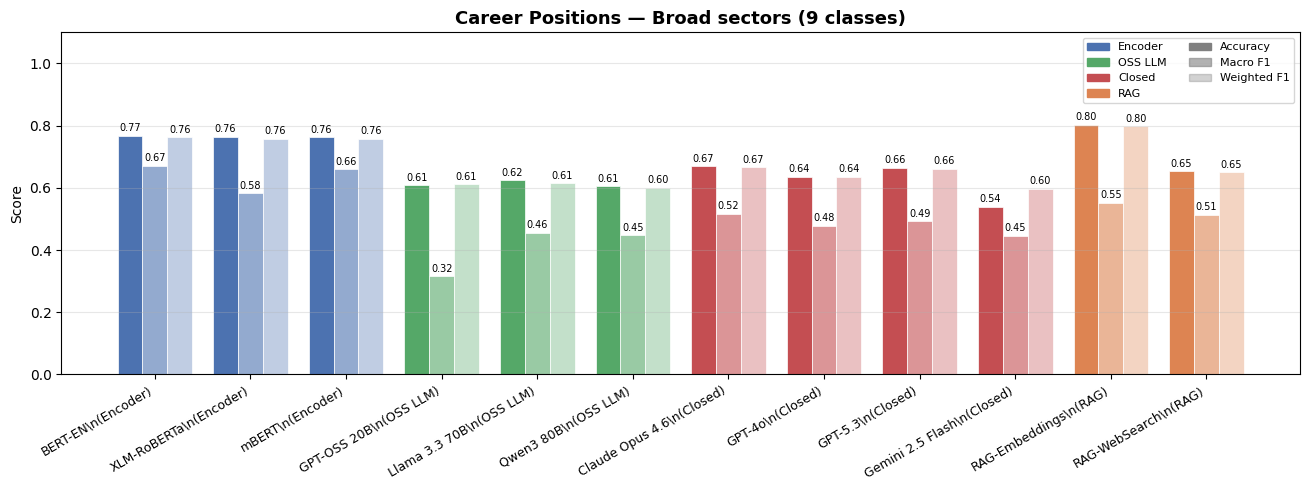

In [43]:
def _rgba(hex_color, alpha):
    """Convert a hex color string + alpha float to an RGBA tuple."""
    r, g, b = mcolors.to_rgb(hex_color)
    return (r, g, b, alpha)

def plot_results(df, title):
    has = df[df["Accuracy"].notna()].copy()
    tbd = df[df["Accuracy"].isna()]["Model"].tolist()

    x   = np.arange(len(has))
    w   = 0.26
    bar_colors = [FAMILY_COLORS[f] for f in has["Family"]]

    fig, ax = plt.subplots(figsize=(max(10, len(has) * 1.1), 5))

    metrics = [("Accuracy", 1.0), ("Macro F1", 0.6), ("Weighted F1", 0.35)]
    for (metric, alpha), offset in zip(metrics, [-w, 0, w]):
        vals = has[metric].values.astype(float)
        colors = [_rgba(c, alpha) for c in bar_colors]
        bars = ax.bar(x + offset, vals, w, color=colors,
                      edgecolor="white", linewidth=0.5, label=metric)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                        f"{val:.2f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r.Model}\\n({r.Family})" for _, r in has.iterrows()],
        fontsize=9, rotation=30, ha="right",
    )
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

    family_patches = [mpatches.Patch(color=FAMILY_COLORS[f], label=f) for f in FAMILY_ORDER]
    metric_patches = [
        mpatches.Patch(color="grey", alpha=1.0,  label="Accuracy"),
        mpatches.Patch(color="grey", alpha=0.6,  label="Macro F1"),
        mpatches.Patch(color="grey", alpha=0.35, label="Weighted F1"),
    ]
    ax.legend(handles=family_patches + metric_patches, fontsize=8, ncol=2, loc="upper right")

    if tbd:
        ax.text(0.01, 0.02, "TBD: " + ", ".join(tbd),
                transform=ax.transAxes, fontsize=8, color="grey", va="bottom")

    plt.tight_layout()
    plt.show()

plot_results(df_broad, "Career Positions — Broad sectors (9 classes)")

## 6. Fine-grained results (~100 codes)

In [44]:
fmt_table(df_fine)

Family,Model,Accuracy,Macro F1,Weighted F1
Encoder,BERT-EN,0.4636,0.1674,0.3943
Encoder,XLM-RoBERTa,0.4548,0.1425,0.3698
Encoder,mBERT,0.4678,0.1608,0.3898
OSS LLM,GPT-OSS 20B,0.1472,0.1016,0.1662
OSS LLM,Llama 3.3 70B,0.1661,0.1184,0.1789
OSS LLM,Qwen3 80B,0.1765,0.1047,0.1639
Closed,Claude Opus 4.6,TBD,TBD,TBD
Closed,GPT-4o,0.2074,0.1345,0.2059
Closed,GPT-5.3,TBD,TBD,TBD
Closed,Gemini 2.5 Flash,0.0777,0.0727,0.1049


In [45]:
print(to_latex(df_fine,
    caption="career\\_position annotation — Fine-grained (\\textasciitilde{}100 codes)",
    label="career_fine"))

\begin{table}[ht]
\centering
\small
\begin{tabular}{llccc}
\toprule
Family & Model & Accuracy & Macro F1 & Weighted F1 \\
\midrule
Encoder & BERT-EN & 0.4636 & 0.1674 & 0.3943 \\
Encoder & XLM-RoBERTa & 0.4548 & 0.1425 & 0.3698 \\
Encoder & mBERT & 0.4678 & 0.1608 & 0.3898 \\
\midrule
OSS LLM & GPT-OSS 20B & 0.1472 & 0.1016 & 0.1662 \\
OSS LLM & Llama 3.3 70B & 0.1661 & 0.1184 & 0.1789 \\
OSS LLM & Qwen3 80B & 0.1765 & 0.1047 & 0.1639 \\
\midrule
Closed & Claude Opus 4.6 & -- & -- & -- \\
Closed & GPT-4o & 0.2074 & 0.1345 & 0.2059 \\
Closed & GPT-5.3 & -- & -- & -- \\
Closed & Gemini 2.5 Flash & 0.0777 & 0.0727 & 0.1049 \\
\midrule
RAG & RAG-Embeddings & -- & -- & -- \\
RAG & RAG-WebSearch & -- & -- & -- \\
\bottomrule
\end{tabular}
\caption{career\_position annotation — Fine-grained (\textasciitilde{}100 codes)}
\label{tab:career_fine}
\end{table}


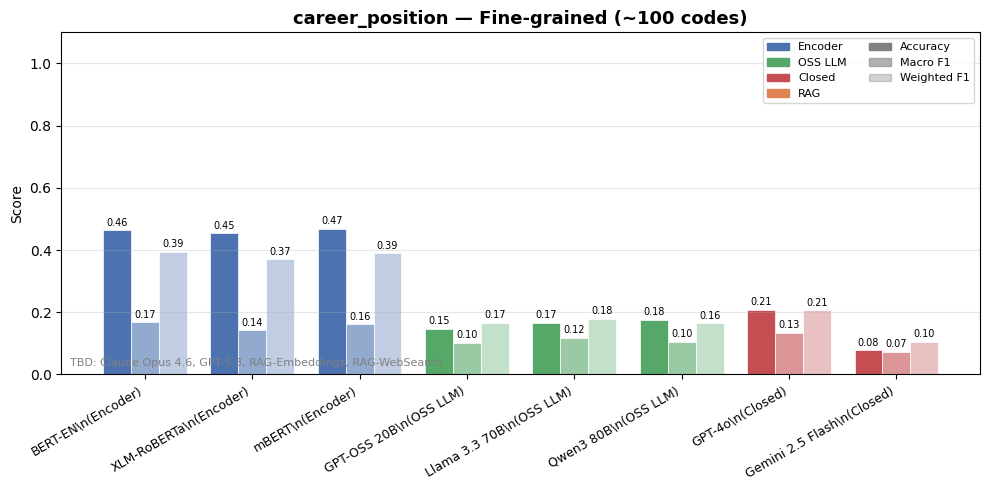

In [46]:
plot_results(df_fine, "career_position — Fine-grained (~100 codes)")

## 7. Broad vs fine — accuracy side-by-side

In [ ]:
merged = (
    df_broad[["Family", "Model", "Accuracy", "Macro F1"]]
    .rename(columns={"Accuracy": "Acc (broad)", "Macro F1": "MF1 (broad)"})
    .merge(
        df_fine[["Model", "Accuracy", "Macro F1"]]
        .rename(columns={"Accuracy": "Acc (fine)", "Macro F1": "MF1 (fine)"}),
        on="Model",
    )
)
has = merged[merged["Acc (broad)"].notna() | merged["Acc (fine)"].notna()].copy()

x = np.arange(len(has))
w = 0.35
bar_colors = [FAMILY_COLORS[f] for f in has["Family"]]

fig, ax = plt.subplots(figsize=(max(10, len(has) * 1.1), 5))

for offset, col, alpha, label in [(-w/2, "Acc (broad)", 1.0, "Broad"), (w/2, "Acc (fine)", 0.45, "Fine")]:
    vals  = has[col].fillna(0).values.astype(float)
    colors = [_rgba(c, alpha) for c in bar_colors]
    bars  = ax.bar(x + offset, vals, w, color=colors, edgecolor="white", label=label)
    for bar, (_, row) in zip(bars, has.iterrows()):
        val = row[col]
        if pd.notna(val) and val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r.Model}\\n({r.Family})" for _, r in has.iterrows()],
    fontsize=9, rotation=30, ha="right",
)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy: Broad vs Fine-grained", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

family_patches = [mpatches.Patch(color=FAMILY_COLORS[f], label=f) for f in FAMILY_ORDER]
gran_patches   = [
    mpatches.Patch(color="grey", alpha=1.0,  label="Broad (solid)"),
    mpatches.Patch(color="grey", alpha=0.45, label="Fine (faded)"),
]
ax.legend(handles=family_patches + gran_patches, fontsize=8, ncol=2, loc="upper right")

tbd = merged[merged["Acc (broad)"].isna() & merged["Acc (fine)"].isna()]["Model"].tolist()
if tbd:
    ax.text(0.01, 0.02, "TBD: " + ", ".join(tbd),
            transform=ax.transAxes, fontsize=8, color="grey", va="bottom")

plt.tight_layout()
plt.show()

## 8. Per-country accuracy

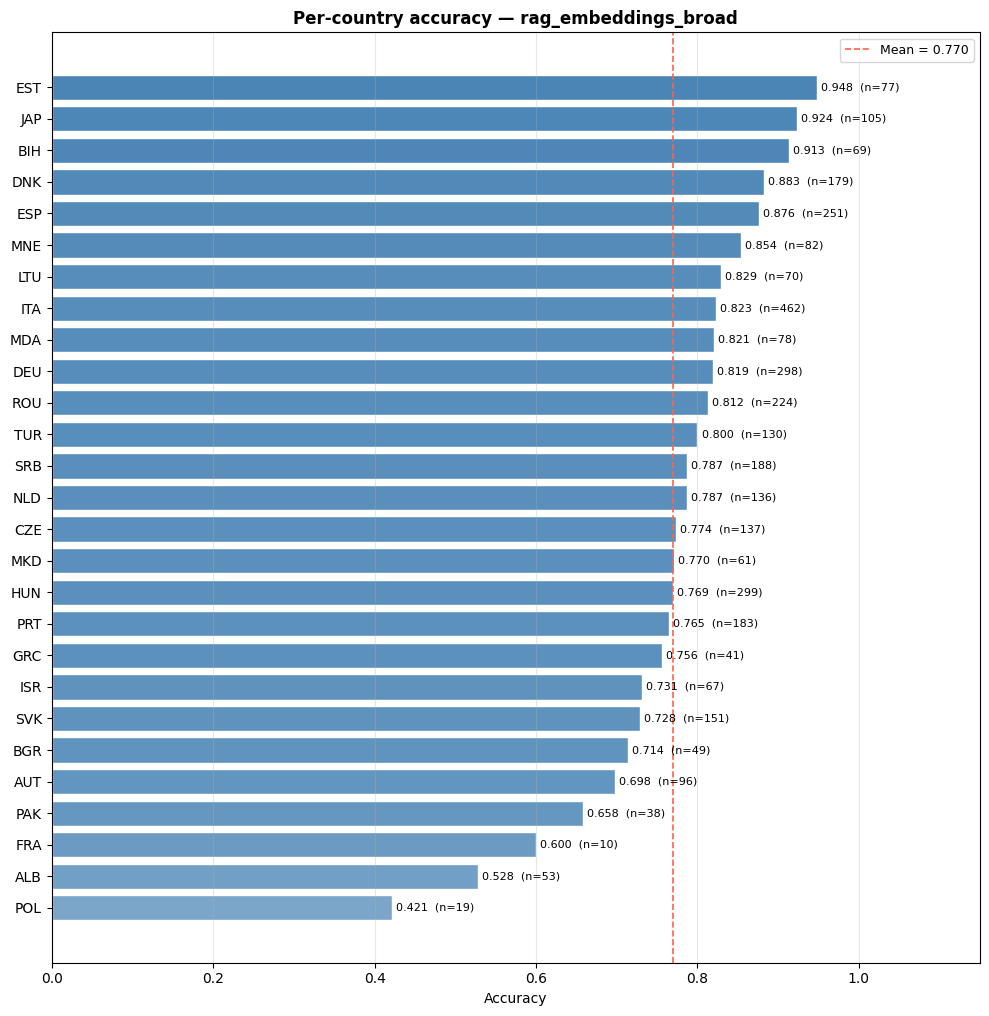

In [48]:
# ── Select model via folder name ─────────────────────────────────────────────
MODEL_FOR_MAP = "rag_embeddings_broad"   # change to any broad folder in reg_best

def get_per_country(folder):
    if folder not in reg_best.index:
        print(f"'{folder}' not in register. Available: {sorted(reg_best.index.tolist())}")
        return {}
    mj = reg_best.loc[folder, "metrics_json"]
    if pd.isna(mj) or not mj:
        return {}
    try:
        return _json.loads(str(mj)).get("per_country", {})
    except Exception as e:
        print(f"JSON parse error: {e}")
        return {}

pc = get_per_country(MODEL_FOR_MAP)
if not pc:
    print("No per-country data found.")
else:
    pc_df = pd.DataFrame([
        {"country": k, "accuracy": v["accuracy"], "n": v["n_evaluated"]}
        for k, v in sorted(pc.items(), key=lambda x: x[1]["accuracy"], reverse=True)
    ])

    fig, ax = plt.subplots(figsize=(10, max(5, len(pc_df) * 0.38)))
    colors = [mcolors.to_rgba(mcolors.CSS4_COLORS["steelblue"], 0.5 + 0.5 * v)
              for v in pc_df["accuracy"]]
    bars = ax.barh(pc_df["country"], pc_df["accuracy"], color=colors, edgecolor="white")
    for bar, (_, row) in zip(bars, pc_df.iterrows()):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{row['accuracy']:.3f}  (n={row['n']:.0f})",
                va="center", fontsize=8)
    ax.set_xlim(0, 1.15)
    ax.set_xlabel("Accuracy")
    ax.set_title(f"Per-country accuracy — {MODEL_FOR_MAP}", fontsize=12, fontweight="bold")
    ax.axvline(pc_df["accuracy"].mean(), color="tomato", linewidth=1.2, linestyle="--",
               label=f"Mean = {pc_df['accuracy'].mean():.3f}")
    ax.legend(fontsize=9)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 9. Per-sector performance (broad models)

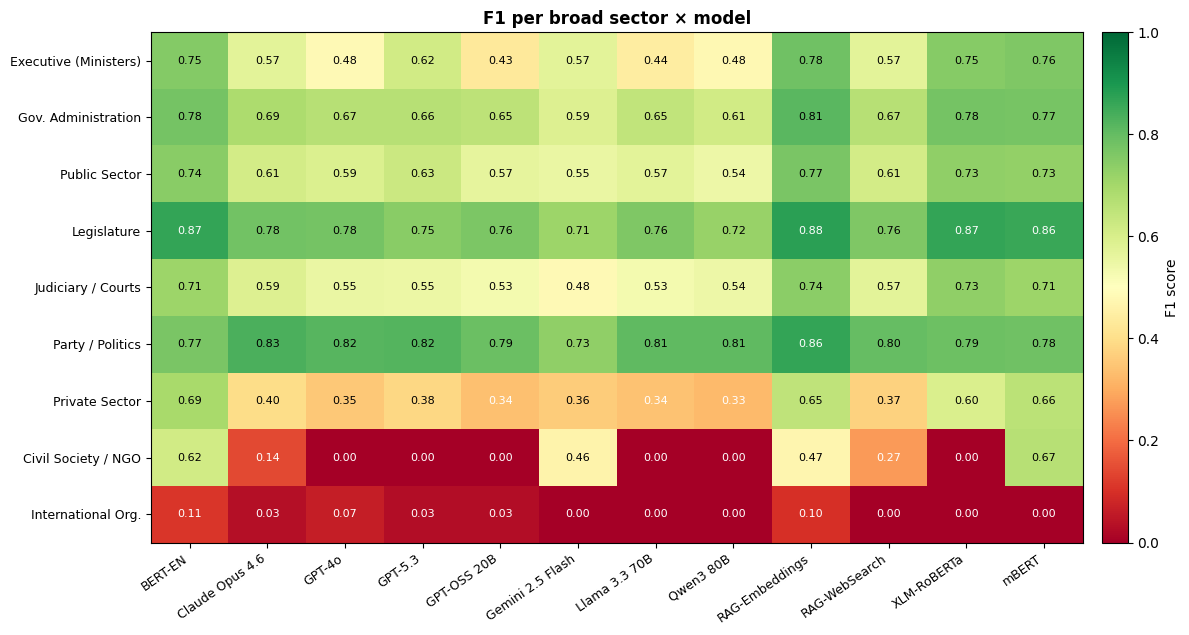

In [49]:
# Collect per_class F1 for all models that have broad results
records = []
for family, name, broad_folder, _ in CATALOGUE:
    if broad_folder not in reg_best.index:
        continue
    mj = reg_best.loc[broad_folder, "metrics_json"]
    if pd.isna(mj) or not mj:
        continue
    try:
        per_class = _json.loads(str(mj)).get("per_class", {})
    except Exception:
        continue
    for sector, metrics in per_class.items():
        records.append({
            "Model":    name,
            "Family":   family,
            "Sector":   sector,
            "Label":    SECTOR_NAMES.get(str(sector), str(sector)),
            "F1":       metrics.get("f1"),
            "Precision": metrics.get("precision"),
            "Recall":   metrics.get("recall"),
            "Support":  metrics.get("support", 0),
        })

sector_df = pd.DataFrame(records)
sector_df["Sector"] = sector_df["Sector"].astype(str)
sector_df = sector_df.sort_values(["Sector", "Family", "Model"])

# ── Heatmap: F1 per sector × model ──────────────────────────────────────────
pivot = sector_df.pivot_table(index="Label", columns="Model", values="F1", aggfunc="mean")
pivot = pivot.reindex(
    [SECTOR_NAMES[s] for s in sorted(SECTOR_NAMES.keys(), key=int) if SECTOR_NAMES[s] in pivot.index]
)

fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 1.0), len(pivot) * 0.55 + 1.5))
im = ax.imshow(pivot.values.astype(float), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="F1 score")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=8, color="black" if 0.35 < v < 0.85 else "white")

ax.set_title("F1 per broad sector × model", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [50]:
# ── Grouped bar: per-sector accuracy across models ───────────────────────────
sectors  = sorted(sector_df["Sector"].unique(), key=int)
models   = sector_df["Model"].unique().tolist()
x        = np.arange(len(sectors))
n_models = len(models)
w        = 0.7 / n_models

fig, ax = plt.subplots(figsize=(13, 5))
for i, model in enumerate(models):
    sub = sector_df[sector_df["Model"] == model].set_index("Sector")
    vals = [float(sub.loc[s, "F1"]) if s in sub.index and pd.notna(sub.loc[s, "F1"]) else 0.0
            for s in sectors]
    fam   = sector_df[sector_df["Model"] == model]["Family"].iloc[0]
    color = FAMILY_COLORS.get(fam, "#999")
    ax.bar(x + i * w, vals, w, color=color,
           alpha=0.4 + 0.6 * (models.index(model) / max(len(models) - 1, 1)),
           label=model, edgecolor="white", linewidth=0.4)

ax.set_xticks(x + w * (n_models - 1) / 2)
ax.set_xticklabels([f"{s}\n{SECTOR_NAMES.get(s, s)}" for s in sectors], fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel("F1 score")
ax.set_title("Per-sector F1 by model (broad)", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend(fontsize=7, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

ValueError: invalid literal for int() with base 10: ''